In [1]:
%pip install pandas numpy matplotlib seaborn statsmodels scipy

Note: you may need to restart the kernel to use updated packages.


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro

In [25]:
df = pd.read_csv(r'C:\Users\OMG\Downloads\marketing_sales_data.csv')
df.head()
print(df.info())
print(df.shape)
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    object 
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), object(2)
memory usage: 22.5+ KB
None
(572, 5)
            Radio  Social Media       Sales
count  572.000000    572.000000  572.000000
mean    17.520616      3.333803  189.296908
std      9.290933      2.238378   89.871581
min      0.109106      0.000031   33.509810
25%     10.699556      1.585549  118.718722
50%     17.149517      3.150111  184.005362
75%     24.606396      4.730408  264.500118
max     42.271579     11.403625  357.788195


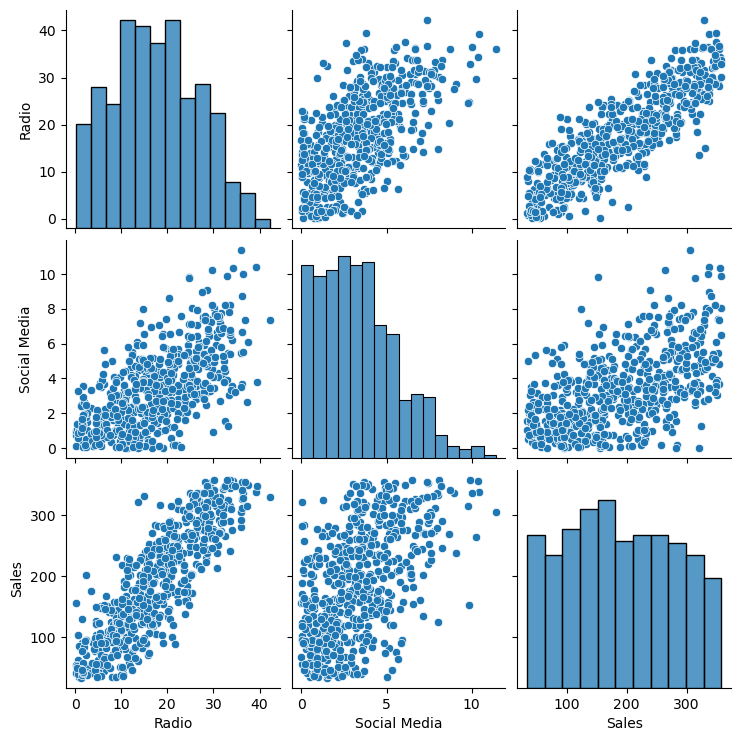

In [26]:
sns.pairplot(df)
plt.show()

In [27]:
priority_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
df['TV'] = df['TV'].map(priority_mapping)

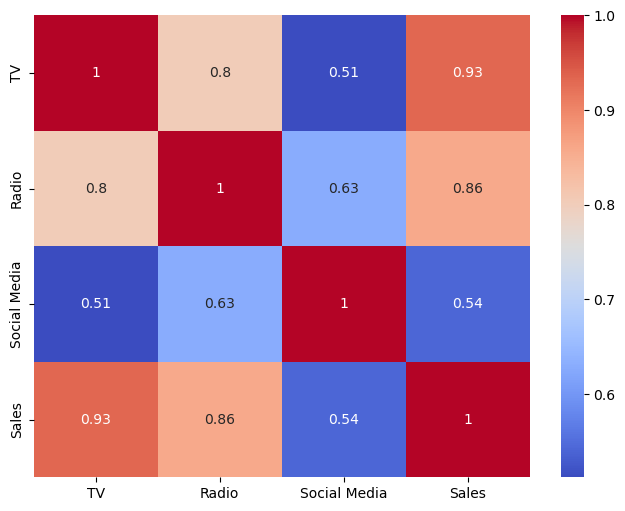

In [28]:
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm') 
plt.show()

In [29]:
print(df.columns.tolist())

['TV', 'Radio', 'Social Media', 'Influencer', 'Sales']


In [30]:
x = df[['TV', 'Radio', 'Social Media']]
y = df['Sales']

In [33]:
x_const = sm.add_constant(x)

vif = pd.DataFrame()
vif['variable'] = x_const.columns
vif['VIF'] = [variance_inflation_factor(x_const.values, i) for i in range(x_const.shape[1])]
print(vif)

       variable       VIF
0         const  7.040920
1            TV  2.820621
2         Radio  3.451590
3  Social Media  1.658144


In [34]:
model = sm.OLS(y, x_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     1781.
Date:                Sat, 20 Jun 2026   Prob (F-statistic):          2.10e-288
Time:                        18:18:36   Log-Likelihood:                -2714.2
No. Observations:                 572   AIC:                             5436.
Df Residuals:                     568   BIC:                             5454.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -12.2889      3.099     -3.966   

In [35]:
predictions = model.predict(x_const)
print(predictions.head())

0     75.153085
1     87.737430
2    280.109361
3    201.833451
4    312.754065
dtype: float64


In [36]:
residuals = model.resid
print(residuals.head())

0   -19.891801
1   -20.162527
2    -7.859253
3    -6.731275
4   -38.793688
dtype: float64


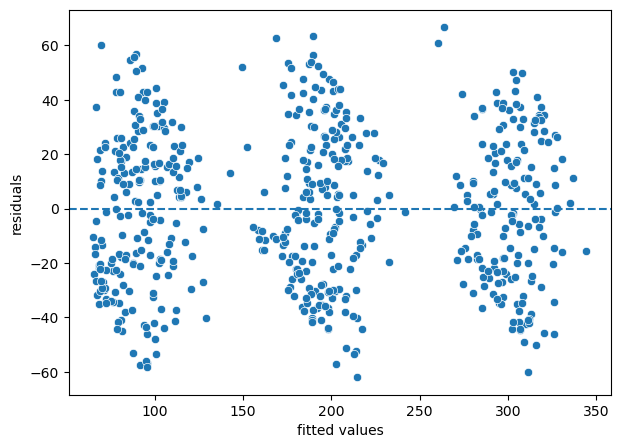

In [37]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    x= model.fittedvalues,
    y= residuals,
)
plt.axhline(y=0, linestyle='--')
plt.xlabel('fitted values')
plt.ylabel('residuals')
plt.show()


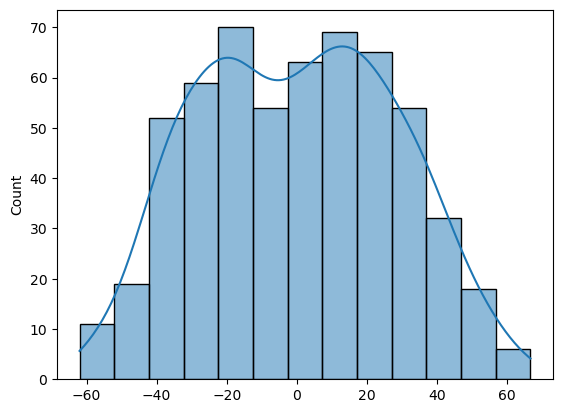

In [38]:
sns.histplot(residuals, kde=True)
plt.show()

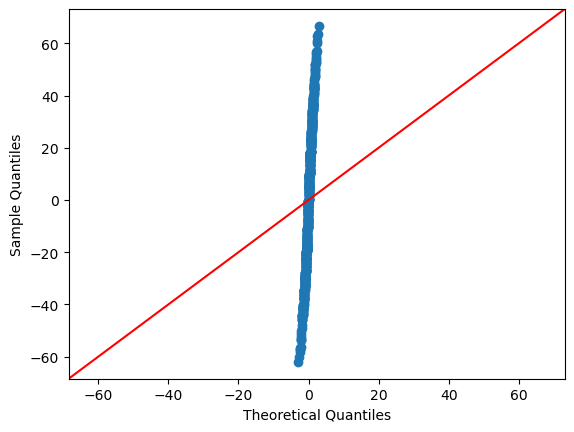

In [39]:
sm.qqplot(residuals, line='45')
plt.show()

In [40]:
stat, p = shapiro(residuals)
print("Statistic:", stat)
print("p-value:", p)

Statistic: 0.983334262036528
p-value: 4.051738456272773e-06


<h1>Business Recommendation</h1>

<p>You can include this in your notebook:</p>

<h2>Marketing Budget Recommendation</h2>

<p>The multiple regression analysis shows that:</p>

<ul>
  <li>TV advertising has a positive and statistically significant impact on sales.</li>
  <li>Radio advertising also contributes significantly to increased sales and exhibits a stronger marginal effect than TV.</li>
  <li>Social Media spending does not significantly affect sales after controlling for TV and Radio expenditure.</li>
</ul>